In [3]:
pip install lasio pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import lasio
las = lasio.read("well.las")
print(las)
df = las.df()
print(df.head())

      COND(DI)  RES(GRD)    SP  RES(DI)  RES(MI)  GAMMA  COMP  CALIPER  \
DEPT                                                                     
0.3        NaN       NaN -99.9      NaN      NaN   52.8  0.08      NaN   
0.4        NaN       NaN -80.2      NaN      NaN   52.9  0.08      NaN   
0.5        NaN       NaN -86.9      NaN      NaN   54.8  0.08      NaN   
0.6        NaN       NaN -88.7      NaN      NaN   55.0  0.08      NaN   
0.7        NaN       NaN -81.1      NaN      NaN   53.9  0.08      NaN   

      DEN(CDL)  TEMP  POR(DEN)  DEL TEMP  
DEPT                                      
0.3       0.24   NaN     -14.0       NaN  
0.4       0.24   NaN     -14.0       NaN  
0.5       0.24   NaN     -14.0       NaN  
0.6       0.24   NaN     -14.0       NaN  
0.7       0.24   NaN     -14.0       NaN  


In [5]:
for curve in las.curves:
    print(curve.mnemonic)

DEPT
COND(DI)
RES(GRD)
SP
RES(DI)
RES(MI)
GAMMA
COMP
CALIPER
DEN(CDL)
TEMP
POR(DEN)
DEL TEMP


In [6]:
import numpy as np
df.replace(-999.25, np.nan, inplace=True)
df = df.dropna()

print(df.isnull().sum())

COND(DI)    0
RES(GRD)    0
SP          0
RES(DI)     0
RES(MI)     0
GAMMA       0
COMP        0
CALIPER     0
DEN(CDL)    0
TEMP        0
POR(DEN)    0
DEL TEMP    0
dtype: int64


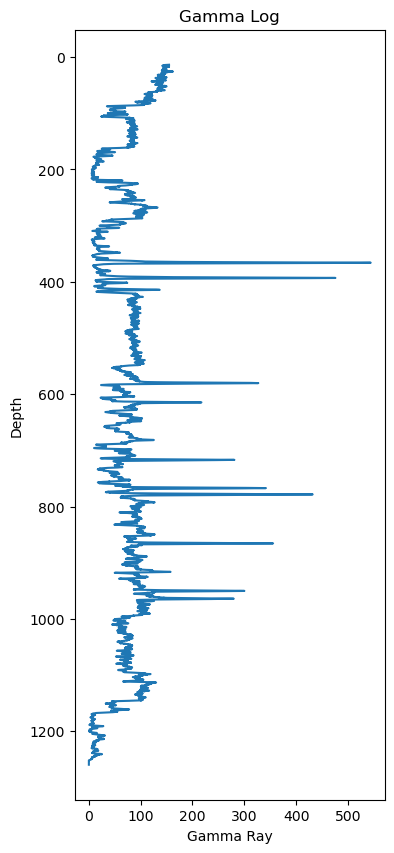

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,10))
plt.plot(df["GAMMA"],df.index)
plt.gca().invert_yaxis()
plt.xlabel("Gamma Ray")
plt.ylabel("Depth")      
plt.title("Gamma Log")
plt.show()

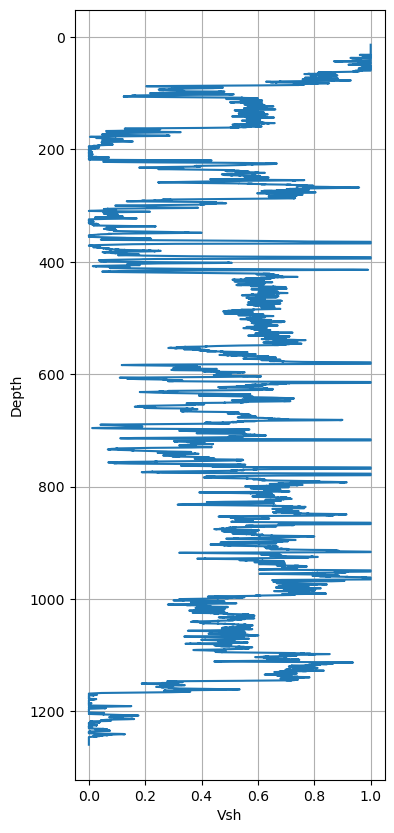

In [8]:
GRmin = df["GAMMA"].quantile(0.05)
GRmax = df["GAMMA"].quantile(0.95)

df["Vsh"] = (df["GAMMA"]-GRmin)/(GRmax-GRmin)
df["Vsh"] = df["Vsh"].clip(0,1)

plt.figure(figsize=(4,10))
plt.plot(df["Vsh"],df.index)
plt.gca().invert_yaxis()
plt.xlabel("Vsh")
plt.ylabel("Depth")
plt.grid()
plt.show()

In [9]:
df["PHI"] = df["POR(DEN)"]

In [10]:
df["Rt"] = df["RES(DI)"]

In [11]:
a = 1
n = 2
m = 2
Rw = 0.1

df["Sw"] = ((a*Rw) / ((df["PHI"]**m)*df["Rt"]))**(1/n)
df["Sw"] = df["Sw"].clip(0,1)

In [12]:
df["Reservoir"] = df["Vsh"] < 0.35

df["Pay"] = (
    (df["Vsh"] < 0.35) &
    (df["PHI"] > 0.10) &
    (df["Sw"] < 0.60)
)

In [13]:
gross = len(df)

net_res = df["Reservoir"].sum()

net_pay = df["Pay"].sum()

print("Gross Intervals:",gross)
print("Net Reservoir:",net_res)
print("Net Pay:",net_pay)

Gross Intervals: 12458
Net Reservoir: 3723
Net Pay: 3664


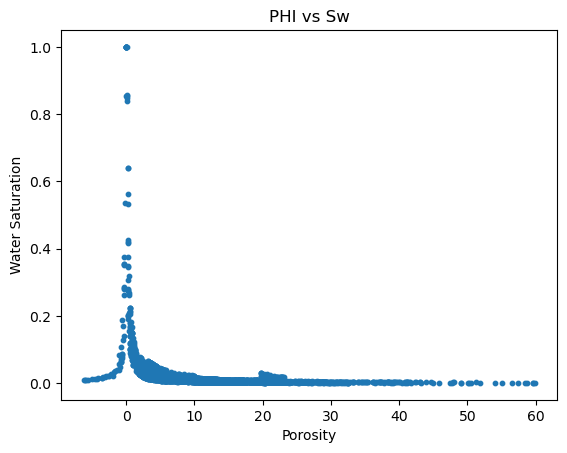

In [14]:
plt.scatter(
df["PHI"],
df["Sw"],
s=10
)

plt.xlabel("Porosity")

plt.ylabel("Water Saturation")

plt.title("PHI vs Sw")
plt.savefig("CrossPlot.png")
plt.show()

In [15]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

# Convert rows to feet (depth step is 0.1 ft)
depth_step = 0.1  # From LAS file header
gross_ft = len(df) * depth_step
reservoir_ft = df["Reservoir"].sum() * depth_step
pay_ft = df["Pay"].sum() * depth_step

print(f"\nSUMMARY STATISTICS:")
print(f"{'='*50}")
print(f"Gross Interval:      {gross_ft:.1f} ft")
print(f"Net Reservoir:       {reservoir_ft:.1f} ft ({df['Reservoir'].sum()/len(df)*100:.1f}%)")
print(f"Net Pay:             {pay_ft:.1f} ft ({df['Pay'].sum()/len(df)*100:.1f}%)")
print(f"{'='*50}")

# Also report in rows for reference
print(f"\n(For reference, in rows: Gross={len(df)}, Reservoir={df['Reservoir'].sum():.0f}, Pay={df['Pay'].sum():.0f})")


FINAL SUMMARY

SUMMARY STATISTICS:
Gross Interval:      1245.8 ft
Net Reservoir:       372.3 ft (29.9%)
Net Pay:             366.4 ft (29.4%)

(For reference, in rows: Gross=12458, Reservoir=3723, Pay=3664)


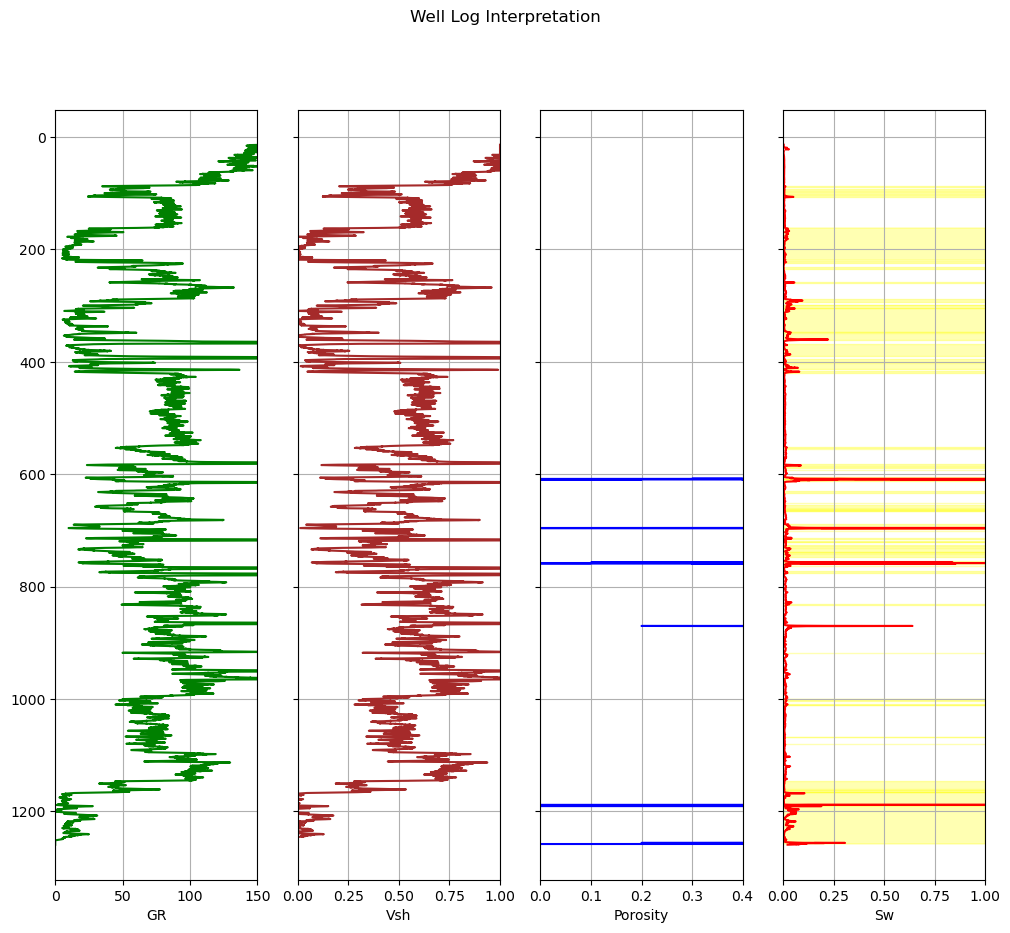

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(12,10), sharey=True)

depth = df.index

# Track 1: Gamma Ray (Green)
ax[0].plot(df["GAMMA"], depth, color="green")
ax[0].set_xlabel("GR")
ax[0].set_xlim(0,150)
ax[0].invert_yaxis()
ax[0].grid()

# Track 2: Vsh (Brown)
ax[1].plot(df["Vsh"], depth, color="brown")
ax[1].set_xlabel("Vsh")
ax[1].set_xlim(0,1)
ax[1].grid()

# Track 3: Porosity (Blue)
ax[2].plot(df["PHI"], depth, color="blue")
ax[2].set_xlabel("Porosity")
ax[2].set_xlim(0,0.4)
ax[2].grid()

# Track 4: Water Saturation (Red)
ax[3].plot(df["Sw"], depth, color="red")
ax[3].set_xlabel("Sw")
ax[3].set_xlim(0,1)
ax[3].grid()

# Highlight Pay Zone (Yellow shading)
ax[3].fill_betweenx(depth, 0, 1, where=df["Pay"], color="yellow", alpha=0.3)

plt.suptitle("Well Log Interpretation")
plt.savefig("Well-Log Fig.png")
plt.show()
